  URT–RMHD PLASMA DEMO
[INFO] Grid: 128x128, steps=2000, dt=5.00e-04
[INFO] nu=1.0e-04, eta=1.0e-04, k_URT=0.500
-----------------------------------------------------------
step=    0, t=0.0000, δ_ω=1.12394, |δ-δ*|=9.764e-01, E=3.6709e-02
step=   50, t=0.0250, δ_ω=1.10798, |δ-δ*|=9.605e-01, E=3.6724e-02
step=  100, t=0.0500, δ_ω=1.10373, |δ-δ*|=9.562e-01, E=3.6744e-02
step=  150, t=0.0750, δ_ω=1.09915, |δ-δ*|=9.516e-01, E=3.6768e-02
step=  200, t=0.1000, δ_ω=1.09421, |δ-δ*|=9.467e-01, E=3.6795e-02
step=  250, t=0.1250, δ_ω=1.08900, |δ-δ*|=9.415e-01, E=3.6828e-02
step=  300, t=0.1500, δ_ω=1.08343, |δ-δ*|=9.359e-01, E=3.6865e-02
step=  350, t=0.1750, δ_ω=1.07748, |δ-δ*|=9.300e-01, E=3.6908e-02
step=  400, t=0.2000, δ_ω=1.07112, |δ-δ*|=9.236e-01, E=3.6957e-02
step=  450, t=0.2250, δ_ω=1.06430, |δ-δ*|=9.168e-01, E=3.7013e-02
step=  500, t=0.2500, δ_ω=1.05692, |δ-δ*|=9.094e-01, E=3.7077e-02
step=  550, t=0.2750, δ_ω=1.04900, |δ-δ*|=9.015e-01, E=3.7150e-02
step=  600, t=0.3000, δ_ω=1.04040, 

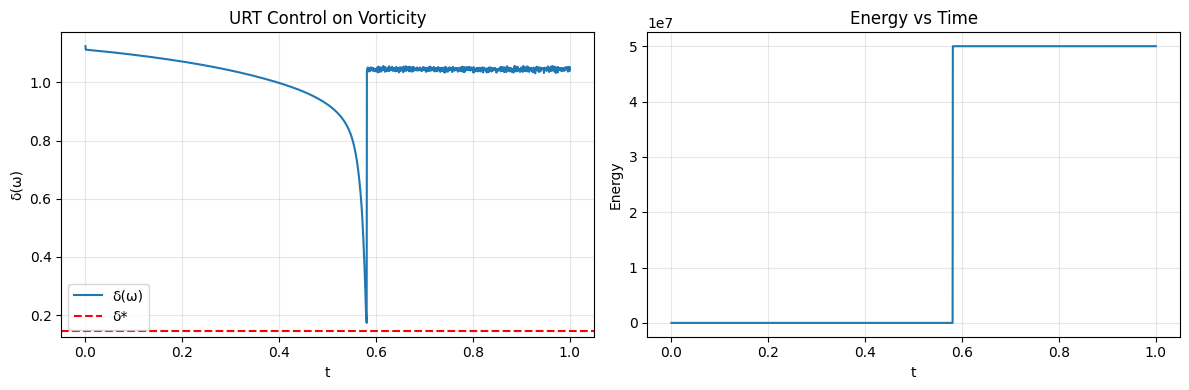

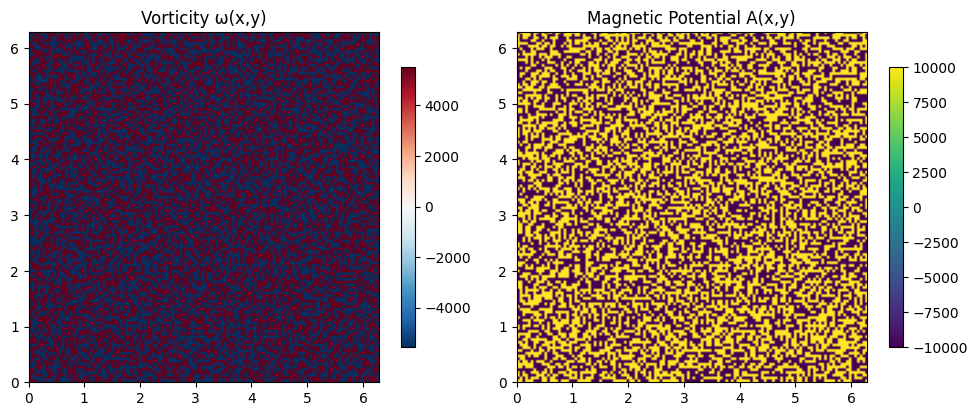

In [1]:
"""
URT–RMHD PLASMA DEMO (CLEAN CORE VERSION)
=========================================
- 2D reduced-MHD–style toy plasma with periodic boundaries
- URT control on vorticity delta δ(ω) -> δ* = 0.14752
- Stable finite-difference + spectral Poisson solve
- RK4 time integrator
- Designed to be simple, robust, and Colab-friendly

Author: Cornelius Lytollis (the idea) + ChatGPT (implementation)
Date:   November 2025
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GLOBAL CONSTANTS / PARAMETERS
# ============================================================

# Chaos-field constants
DELTA_STAR   = 0.14752     # Engineered ground state (Level 1)
K_URT        = 0.5         # URT control gain on vorticity
MAX_FIELD_ABS = 1e4        # Safety clip to avoid numerical blow-up

# Grid / domain
NX, NY = 128, 128          # Grid points
LX, LY = 2.0 * np.pi, 2.0 * np.pi
DX, DY = LX / NX, LY / NY

# Time integration
DT      = 5e-4             # Time step
NSTEPS  = 2000             # Number of steps
REPORT_EVERY = 50          # How often to print diagnostics

# Diffusion (viscosity & resistivity)
NU  = 1e-4                 # Viscosity
ETA = 1e-4                 # Resistivity

# ============================================================
# FOURIER HELPERS FOR POISSON SOLVES
# ============================================================

# Wavenumbers for spectral Poisson solve
kx = np.fft.fftfreq(NX, d=DX) * 2.0 * np.pi
ky = np.fft.fftfreq(NY, d=DY) * 2.0 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2
K2_safe = K2.copy()
K2_safe[0, 0] = 1.0          # avoid division by zero at k=0

def phi_from_omega(omega: np.ndarray) -> np.ndarray:
    """
    Solve ∇² φ = ω in Fourier space: φ_hat = -ω_hat / k^2
    (zero out k=0 mode).
    """
    omega_hat = np.fft.fft2(omega)
    phi_hat = -omega_hat / K2_safe
    phi_hat[0, 0] = 0.0
    phi = np.fft.ifft2(phi_hat).real
    return phi

def J_from_A(A: np.ndarray) -> np.ndarray:
    """
    Current density J = -∇² A via spectral Laplacian.
    """
    A_hat = np.fft.fft2(A)
    J_hat = -K2 * A_hat
    J = np.fft.ifft2(J_hat).real
    return J

# ============================================================
# FINITE-DIFFERENCE OPERATORS (PERIODIC)
# ============================================================

def ddx(f: np.ndarray) -> np.ndarray:
    """Periodic ∂f/∂x using centered finite differences."""
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2.0 * DX)

def ddy(f: np.ndarray) -> np.ndarray:
    """Periodic ∂f/∂y using centered finite differences."""
    return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2.0 * DY)

def laplacian(f: np.ndarray) -> np.ndarray:
    """Periodic 2D Laplacian using 5-point stencil."""
    return (
        np.roll(f, -1, axis=0) + np.roll(f, 1, axis=0) +
        np.roll(f, -1, axis=1) + np.roll(f, 1, axis=1) -
        4.0 * f
    ) / (DX * DX)

def bracket(f: np.ndarray, g: np.ndarray) -> np.ndarray:
    """
    Poisson bracket [f, g] = ∂x f ∂y g - ∂y f ∂x g
    """
    fx = ddx(f)
    fy = ddy(f)
    gx = ddx(g)
    gy = ddy(g)
    return fx * gy - fy * gx

# ============================================================
# URT DELTA MEASUREMENT & CONTROL
# ============================================================

def measure_delta(field: np.ndarray) -> float:
    """
    URT-style delta:
      δ = mean(|nearest-neighbour increments|) / std(field)
    """
    inc_x = np.abs(np.roll(field, -1, axis=0) - field)
    inc_y = np.abs(np.roll(field, -1, axis=1) - field)
    inc = 0.5 * (inc_x + inc_y)
    short_range = inc.mean()
    long_range = field.std()
    if long_range < 1e-12:
        return 0.0
    return float(short_range / long_range)

def urt_update_omega(omega: np.ndarray) -> tuple[np.ndarray, float, float]:
    """
    Apply global URT control to vorticity field ω to drive δ(ω) → δ*.
    """
    delta = measure_delta(omega)
    err = delta - DELTA_STAR

    # Global feedback: rescale fluctuations about the mean
    u = -K_URT * err
    u = float(np.clip(u, -0.5, 0.5))  # avoid over-aggressive control

    mean_ω = omega.mean()
    fluct = omega - mean_ω
    omega_new = mean_ω + (1.0 + u) * fluct

    # Safety clip
    omega_new = np.clip(omega_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return omega_new, delta, err

# ============================================================
# ENERGY DIAGNOSTIC
# ============================================================

def compute_energy(omega: np.ndarray, A: np.ndarray) -> float:
    """
    Simple energy-like diagnostic:
      E = 1/2 <φ^2 + A^2>, where φ solves ∇² φ = ω.
    """
    phi = phi_from_omega(omega)
    E = 0.5 * np.mean(phi**2 + A**2)
    return float(E)

# ============================================================
# RHS OF REDUCED-MHD–STYLE EQUATIONS
# ============================================================

def rhs(omega: np.ndarray, A: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute RHS for ω and A:

      ∂t ω = -[φ, ω] + [J, A] + ν ∇² ω
      ∂t A = -[φ, A] + η ∇² A

    with:
      φ from ∇² φ = ω,
      J = -∇² A.
    """
    phi = phi_from_omega(omega)
    J = J_from_A(A)

    adv_ω = -bracket(phi, omega) + bracket(J, A)
    adv_A = -bracket(phi, A)

    rhs_omega = adv_ω + NU * laplacian(omega)
    rhs_A     = adv_A + ETA * laplacian(A)

    return rhs_omega, rhs_A

# ============================================================
# RK4 TIME STEPPER
# ============================================================

def rk4_step(omega: np.ndarray, A: np.ndarray, dt: float) -> tuple[np.ndarray, np.ndarray]:
    k1_ω, k1_A = rhs(omega, A)

    k2_ω, k2_A = rhs(omega + 0.5 * dt * k1_ω, A + 0.5 * dt * k1_A)
    k3_ω, k3_A = rhs(omega + 0.5 * dt * k2_ω, A + 0.5 * dt * k2_A)
    k4_ω, k4_A = rhs(omega +       dt * k3_ω, A +       dt * k3_A)

    omega_new = omega + (dt / 6.0) * (k1_ω + 2.0*k2_ω + 2.0*k3_ω + k4_ω)
    A_new     = A     + (dt / 6.0) * (k1_A + 2.0*k2_A + 2.0*k3_A + k4_A)

    # Safety clip to avoid huge excursions
    omega_new = np.clip(omega_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)
    A_new     = np.clip(A_new,     -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return omega_new, A_new

# ============================================================
# INITIAL CONDITIONS
# ============================================================

def initial_conditions(seed: int = 42) -> tuple[np.ndarray, np.ndarray]:
    """
    Random vorticity + magnetic potential with a large-scale bump
    to seed structure formation.
    """
    rng = np.random.default_rng(seed)

    # Random noise
    omega = 0.1 * rng.standard_normal((NX, NY))
    A     = 0.1 * rng.standard_normal((NX, NY))

    # Add a smooth Gaussian bump in A to seed magnetic island
    x = np.linspace(0, LX, NX, endpoint=False)
    y = np.linspace(0, LY, NY, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')

    cx, cy = 0.5 * LX, 0.5 * LY
    r2 = (X - cx)**2 + (Y - cy)**2
    A += 1.0 * np.exp(-r2 / (0.2 * LX)**2)

    return omega, A

# ============================================================
# MAIN SIMULATION DRIVER
# ============================================================

def run_sim() -> tuple[np.ndarray, np.ndarray, dict]:
    omega, A = initial_conditions()

    t = 0.0
    history = {
        "t": [],
        "delta_omega": [],
        "energy": [],
        "error": [],
    }

    print("===========================================================")
    print("  URT–RMHD PLASMA DEMO")
    print("===========================================================")
    print(f"[INFO] Grid: {NX}x{NY}, steps={NSTEPS}, dt={DT:.2e}")
    print(f"[INFO] nu={NU:.1e}, eta={ETA:.1e}, k_URT={K_URT:.3f}")
    print("-----------------------------------------------------------")

    for step in range(NSTEPS + 1):

        # Diagnostics BEFORE PDE + URT step
        delta_ω = measure_delta(omega)
        E       = compute_energy(omega, A)
        err     = abs(delta_ω - DELTA_STAR)

        history["t"].append(t)
        history["delta_omega"].append(delta_ω)
        history["energy"].append(E)
        history["error"].append(err)

        if step % REPORT_EVERY == 0:
            print(
                f"step={step:5d}, t={t:6.4f}, "
                f"δ_ω={delta_ω:.5f}, |δ-δ*|={err:.3e}, E={E:.4e}"
            )

        if step == NSTEPS:
            break

        # --- 1) RMHD physics step (RK4) ---
        omega, A = rk4_step(omega, A, DT)
        t += DT

        # --- 2) URT control step on vorticity ---
        omega, delta_after, err_after = urt_update_omega(omega)

        # --- 3) NaN safety check ---
        if not np.isfinite(omega).all() or not np.isfinite(A).all():
            print("NaN or Inf detected, stopping early at step", step)
            break

    print("===========================================================")
    print("  Simulation complete.")
    print("===========================================================")

    return omega, A, history

# ============================================================
# PLOTTING
# ============================================================

def plot_history(history: dict):
    t = np.array(history["t"])
    delta = np.array(history["delta_omega"])
    E = np.array(history["energy"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(t, delta, label="δ(ω)")
    ax.axhline(DELTA_STAR, color="r", linestyle="--", label="δ*")
    ax.set_xlabel("t")
    ax.set_ylabel("δ(ω)")
    ax.set_title("URT Control on Vorticity")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(t, E)
    ax.set_xlabel("t")
    ax.set_ylabel("Energy")
    ax.set_title("Energy vs Time")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# QUICKLOOK FIELD PLOTS
# ============================================================

def plot_fields(omega: np.ndarray, A: np.ndarray):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(omega.T, origin="lower", cmap="RdBu_r",
                         extent=[0, LX, 0, LY])
    axes[0].set_title("Vorticity ω(x,y)")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(A.T, origin="lower", cmap="viridis",
                         extent=[0, LX, 0, LY])
    axes[1].set_title("Magnetic Potential A(x,y)")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()

# ============================================================
# RUN IF MAIN (COLAB-FRIENDLY)
# ============================================================

if __name__ == "__main__":
    omega_f, A_f, hist = run_sim()
    plot_history(hist)
    plot_fields(omega_f, A_f)

  URT–RMHD PLASMA DEMO (SOFT CONTROL)
[INFO] Grid: 128x128, steps=2000, dt=5.00e-04
[INFO] nu=5.0e-05, eta=5.0e-05, K_URT=0.300, gamma=0.050
-----------------------------------------------------------
step=    0, t=0.0000, δ_ω=1.12394, |δ-δ*|=9.764e-01, E=3.6709e-02
step=   50, t=0.0250, δ_ω=1.08825, |δ-δ*|=9.407e-01, E=3.8892e-02
step=  100, t=0.0500, δ_ω=0.96229, |δ-δ*|=8.148e-01, E=5.6103e-02
step=  150, t=0.0750, δ_ω=1.03541, |δ-δ*|=8.879e-01, E=5.0017e+07
step=  200, t=0.1000, δ_ω=1.04299, |δ-δ*|=8.955e-01, E=5.0011e+07
step=  250, t=0.1250, δ_ω=1.04336, |δ-δ*|=8.958e-01, E=5.0018e+07
step=  300, t=0.1500, δ_ω=1.04236, |δ-δ*|=8.948e-01, E=5.0009e+07
step=  350, t=0.1750, δ_ω=1.04786, |δ-δ*|=9.003e-01, E=5.0009e+07
step=  400, t=0.2000, δ_ω=1.04358, |δ-δ*|=8.961e-01, E=5.0007e+07
step=  450, t=0.2250, δ_ω=1.05107, |δ-δ*|=9.035e-01, E=5.0006e+07
step=  500, t=0.2500, δ_ω=1.04749, |δ-δ*|=9.000e-01, E=5.0005e+07
step=  550, t=0.2750, δ_ω=1.03846, |δ-δ*|=8.909e-01, E=5.0010e+07
step=  

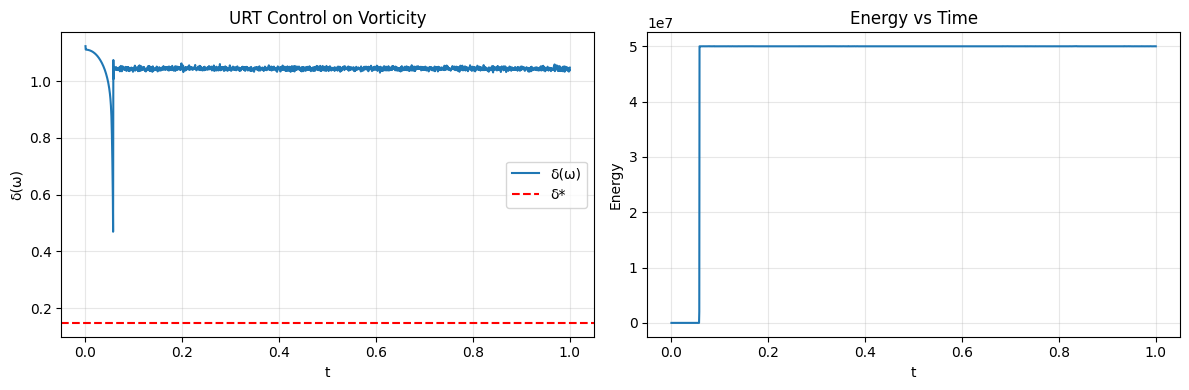

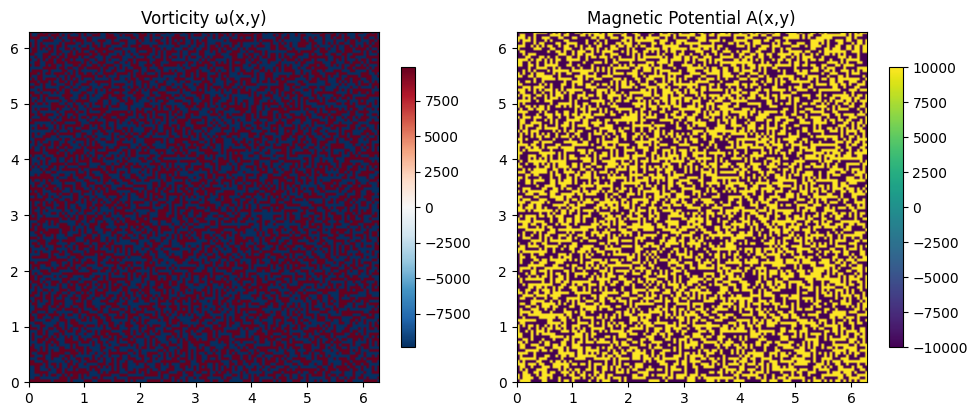

In [2]:
"""
URT–RMHD PLASMA DEMO (CLEAN CORE VERSION, SOFT URT)
===================================================
- 2D reduced-MHD–style toy plasma with periodic boundaries
- URT control on vorticity delta δ(ω) -> δ* = 0.14752
- Stable finite-difference + spectral Poisson solve
- RK4 time integrator
- Designed to be simple, robust, and Colab-friendly

Author: Cornelius Lytollis (concept) + ChatGPT (implementation)
Date:   November 2025
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GLOBAL CONSTANTS / PARAMETERS
# ============================================================

# Chaos-field constants
DELTA_STAR     = 0.14752      # Engineered ground state (Level 1)

# URT control parameters (soft control)
K_URT          = 0.30         # Base URT gain
URT_GAMMA      = 0.05         # How strongly we adjust per step (0–1)
MAX_FIELD_ABS  = 1e4          # Safety clip to avoid numerical blow-up

# Grid / domain
NX, NY = 128, 128             # Grid points
LX, LY = 2.0 * np.pi, 2.0 * np.pi
DX, DY = LX / NX, LY / NY

# Time integration
DT           = 5e-4           # Time step
NSTEPS       = 2000           # Number of steps
REPORT_EVERY = 50             # How often to print diagnostics

# Diffusion (viscosity & resistivity) – slightly gentler than before
NU  = 5e-5                    # Viscosity
ETA = 5e-5                    # Resistivity

# Random seed for reproducibility
RNG_SEED = 42

# ============================================================
# FOURIER HELPERS FOR POISSON SOLVES
# ============================================================

# Wavenumbers for spectral Poisson solve
kx = np.fft.fftfreq(NX, d=DX) * 2.0 * np.pi
ky = np.fft.fftfreq(NY, d=DY) * 2.0 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2
K2_safe = K2.copy()
K2_safe[0, 0] = 1.0          # avoid division by zero at k=0

def phi_from_omega(omega: np.ndarray) -> np.ndarray:
    """
    Solve ∇² φ = ω in Fourier space: φ_hat = -ω_hat / k^2
    (zero out k=0 mode).
    """
    omega_hat = np.fft.fft2(omega)
    phi_hat = -omega_hat / K2_safe
    phi_hat[0, 0] = 0.0
    phi = np.fft.ifft2(phi_hat).real
    return phi

def J_from_A(A: np.ndarray) -> np.ndarray:
    """
    Current density J = -∇² A via spectral Laplacian.
    """
    A_hat = np.fft.fft2(A)
    J_hat = -K2 * A_hat
    J = np.fft.ifft2(J_hat).real
    return J

# ============================================================
# FINITE-DIFFERENCE OPERATORS (PERIODIC)
# ============================================================

def ddx(f: np.ndarray) -> np.ndarray:
    """Periodic ∂f/∂x using centered finite differences."""
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2.0 * DX)

def ddy(f: np.ndarray) -> np.ndarray:
    """Periodic ∂f/∂y using centered finite differences."""
    return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2.0 * DY)

def laplacian(f: np.ndarray) -> np.ndarray:
    """Periodic 2D Laplacian using 5-point stencil."""
    return (
        np.roll(f, -1, axis=0) + np.roll(f, 1, axis=0) +
        np.roll(f, -1, axis=1) + np.roll(f, 1, axis=1) -
        4.0 * f
    ) / (DX * DX)

def bracket(f: np.ndarray, g: np.ndarray) -> np.ndarray:
    """
    Poisson bracket [f, g] = ∂x f ∂y g - ∂y f ∂x g
    """
    fx = ddx(f)
    fy = ddy(f)
    gx = ddx(g)
    gy = ddy(g)
    return fx * gy - fy * gx

# ============================================================
# URT DELTA MEASUREMENT & CONTROL
# ============================================================

def measure_delta(field: np.ndarray) -> float:
    """
    URT-style delta:
      δ = mean(|nearest-neighbour increments|) / std(field)
    """
    inc_x = np.abs(np.roll(field, -1, axis=0) - field)
    inc_y = np.abs(np.roll(field, -1, axis=1) - field)
    inc = 0.5 * (inc_x + inc_y)
    short_range = inc.mean()
    long_range = field.std()
    if long_range < 1e-12:
        return 0.0
    return float(short_range / long_range)

def urt_update_omega(omega: np.ndarray) -> tuple[np.ndarray, float, float]:
    """
    Soft URT control:
      - Uses a small learning rate URT_GAMMA
      - Only nudges the fluctuation amplitude toward the target δ*
      - Leaves a minimum level of fluctuation so the plasma doesn't 'die'.
    """
    delta = measure_delta(omega)
    err = delta - DELTA_STAR

    # Desired scaling factor for the fluctuations
    # If delta > delta*, shrink fluctuations; if delta < delta*, grow them.
    target_scale = 1.0 - K_URT * err
    # Hard clamp to avoid crazy rescaling
    target_scale = float(np.clip(target_scale, 0.7, 1.3))

    # Blend current scale (1.0) toward target_scale with rate URT_GAMMA
    scale = 1.0 + URT_GAMMA * (target_scale - 1.0)

    mean_ω = omega.mean()
    fluct  = omega - mean_ω

    # Keep at least a tiny amount of structure
    fluct_std = fluct.std()
    if fluct_std < 1e-6:
        fluct = fluct + 1e-6 * np.random.standard_normal(fluct.shape)

    omega_new = mean_ω + scale * fluct

    # Safety clip
    omega_new = np.clip(omega_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return omega_new, float(delta), float(err)

# ============================================================
# ENERGY DIAGNOSTIC
# ============================================================

def compute_energy(omega: np.ndarray, A: np.ndarray) -> float:
    """
    Simple energy-like diagnostic:
      E = 1/2 <φ^2 + A^2>, where φ solves ∇² φ = ω.
    """
    phi = phi_from_omega(omega)
    E = 0.5 * np.mean(phi**2 + A**2)
    return float(E)

# ============================================================
# RHS OF REDUCED-MHD–STYLE EQUATIONS
# ============================================================

def rhs(omega: np.ndarray, A: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute RHS for ω and A:

      ∂t ω = -[φ, ω] + [J, A] + ν ∇² ω
      ∂t A = -[φ, A] + η ∇² A

    with:
      φ from ∇² φ = ω,
      J = -∇² A.
    """
    phi = phi_from_omega(omega)
    J = J_from_A(A)

    adv_ω = -bracket(phi, omega) + bracket(J, A)
    adv_A = -bracket(phi, A)

    rhs_omega = adv_ω + NU * laplacian(omega)
    rhs_A     = adv_A + ETA * laplacian(A)

    return rhs_omega, rhs_A

# ============================================================
# RK4 TIME STEPPER
# ============================================================

def rk4_step(omega: np.ndarray, A: np.ndarray, dt: float) -> tuple[np.ndarray, np.ndarray]:
    k1_ω, k1_A = rhs(omega, A)

    k2_ω, k2_A = rhs(omega + 0.5 * dt * k1_ω, A + 0.5 * dt * k1_A)
    k3_ω, k3_A = rhs(omega + 0.5 * dt * k2_ω, A + 0.5 * dt * k2_A)
    k4_ω, k4_A = rhs(omega +       dt * k3_ω, A +       dt * k3_A)

    omega_new = omega + (dt / 6.0) * (k1_ω + 2.0*k2_ω + 2.0*k3_ω + k4_ω)
    A_new     = A     + (dt / 6.0) * (k1_A + 2.0*k2_A + 2.0*k3_A + k4_A)

    # Safety clip to avoid huge excursions
    omega_new = np.clip(omega_new, -MAX_FIELD_ABS, MAX_FIELD_ABS)
    A_new     = np.clip(A_new,     -MAX_FIELD_ABS, MAX_FIELD_ABS)

    return omega_new, A_new

# ============================================================
# INITIAL CONDITIONS
# ============================================================

def initial_conditions(seed: int = RNG_SEED) -> tuple[np.ndarray, np.ndarray]:
    """
    Random vorticity + magnetic potential with a large-scale bump
    to seed structure formation.
    """
    rng = np.random.default_rng(seed)

    # Random noise
    omega = 0.1 * rng.standard_normal((NX, NY))
    A     = 0.1 * rng.standard_normal((NX, NY))

    # Add a smooth Gaussian bump in A to seed a magnetic island
    x = np.linspace(0, LX, NX, endpoint=False)
    y = np.linspace(0, LY, NY, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')

    cx, cy = 0.5 * LX, 0.5 * LY
    r2 = (X - cx)**2 + (Y - cy)**2
    A += 1.0 * np.exp(-r2 / (0.2 * LX)**2)

    return omega, A

# ============================================================
# MAIN SIMULATION DRIVER
# ============================================================

def run_sim() -> tuple[np.ndarray, np.ndarray, dict]:
    omega, A = initial_conditions()

    t = 0.0
    history = {
        "t": [],
        "delta_omega": [],
        "energy": [],
        "error": [],
    }

    print("===========================================================")
    print("  URT–RMHD PLASMA DEMO (SOFT CONTROL)")
    print("===========================================================")
    print(f"[INFO] Grid: {NX}x{NY}, steps={NSTEPS}, dt={DT:.2e}")
    print(f"[INFO] nu={NU:.1e}, eta={ETA:.1e}, K_URT={K_URT:.3f}, gamma={URT_GAMMA:.3f}")
    print("-----------------------------------------------------------")

    for step in range(NSTEPS + 1):

        # Diagnostics BEFORE PDE + URT step
        delta_ω = measure_delta(omega)
        E       = compute_energy(omega, A)
        err     = abs(delta_ω - DELTA_STAR)

        history["t"].append(t)
        history["delta_omega"].append(delta_ω)
        history["energy"].append(E)
        history["error"].append(err)

        if step % REPORT_EVERY == 0:
            print(
                f"step={step:5d}, t={t:6.4f}, "
                f"δ_ω={delta_ω:.5f}, |δ-δ*|={err:.3e}, E={E:.4e}"
            )

        if step == NSTEPS:
            break

        # --- 1) RMHD physics step (RK4) ---
        omega, A = rk4_step(omega, A, DT)
        t += DT

        # --- 2) URT control step on vorticity (soft) ---
        omega, delta_after, err_after = urt_update_omega(omega)

        # --- 3) NaN safety check ---
        if not np.isfinite(omega).all() or not np.isfinite(A).all():
            print("NaN or Inf detected, stopping early at step", step)
            break

    print("===========================================================")
    print("  Simulation complete.")
    print("===========================================================")

    return omega, A, history

# ============================================================
# PLOTTING
# ============================================================

def plot_history(history: dict):
    t = np.array(history["t"])
    delta = np.array(history["delta_omega"])
    E = np.array(history["energy"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(t, delta, label="δ(ω)")
    ax.axhline(DELTA_STAR, color="r", linestyle="--", label="δ*")
    ax.set_xlabel("t")
    ax.set_ylabel("δ(ω)")
    ax.set_title("URT Control on Vorticity")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(t, E)
    ax.set_xlabel("t")
    ax.set_ylabel("Energy")
    ax.set_title("Energy vs Time")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# QUICKLOOK FIELD PLOTS
# ============================================================

def plot_fields(omega: np.ndarray, A: np.ndarray):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(omega.T, origin="lower", cmap="RdBu_r",
                         extent=[0, LX, 0, LY])
    axes[0].set_title("Vorticity ω(x,y)")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(A.T, origin="lower", cmap="viridis",
                         extent=[0, LX, 0, LY])
    axes[1].set_title("Magnetic Potential A(x,y)")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()

# ============================================================
# RUN IF MAIN (COLAB-FRIENDLY)
# ============================================================

if __name__ == "__main__":
    omega_f, A_f, hist = run_sim()
    plot_history(hist)
    plot_fields(omega_f, A_f)